# **Data Understanding**

Features:

UDI:
A unique identifier for each record, used only for indexing and has no impact on predicting machine failure.

Product ID:
A unique code representing each product, used for identification purposes only and does not contribute to the prediction.

Type:
The type/quality of the machine (L: Low, M: Medium, H: High), a categorical feature that may influence failure rates.

Air temperature [K]:
The ambient air temperature surrounding the machine, an important factor that can affect machine performance and overheating risk.

Process temperature [K]:
The operating temperature of the machine during the process, higher values may indicate stress or potential failure conditions.

Rotational speed [rpm]:
The speed at which the machine operates, measured in revolutions per minute, critical for understanding mechanical stress.

Torque [Nm]:
The torque applied during operation, representing the load on the machine, where abnormal values may signal potential issues.

Tool wear [min]:
The duration of tool usage in minutes, indicating how worn out the tool is; higher values increase the likelihood of failure.

TWF (Tool Wear Failure):
Indicates whether the failure was caused by excessive tool wear (1) or not (0).

HDF (Heat Dissipation Failure):
Indicates failure due to insufficient heat dissipation (1) or not (0).

PWF (Power Failure):
Indicates failure caused by power-related issues (1) or not (0).

OSF (Overstrain Failure):
Indicates failure due to mechanical overstrain (1) or not (0).

RNF (Random Failure):
Indicates failure caused by random, unpredictable reasons (1) or not (0).

Target:

Machine failure:
The target variable, indicating whether the machine has failed (1) or is operating normally (0).


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Explore**

In [2]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d stephanmatzka/predictive-maintenance-dataset-ai4i-2020

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
License(s): CC-BY-NC-SA-4.0
100% 136k/136k [00:00<00:00, 450kB/s]



In [3]:
!unzip /content/predictive-maintenance-dataset-ai4i-2020.zip

Archive:  /content/predictive-maintenance-dataset-ai4i-2020.zip
  inflating: ai4i2020.csv            


In [4]:
import pandas as pd
df = pd.read_csv("/content/ai4i2020.csv")

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.tail(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [10]:
df.shape

(10000, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Important Insight:

* The dataset is very clean with no missing values, which simplifies preprocessing and improves data reliability.

* It contains strong numerical features that are directly suitable for machine learning models.

* There is only one categorical feature (Type), making encoding straightforward and reducing preprocessing complexity.


In [11]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


 The dataset shows a strong class imbalance, where normal operations (0) significantly outnumber machine failures (1).

In [12]:
df["Type"].unique()
df["Type"].value_counts()

,count
Type,
L,6000
M,2997
H,1003


There is an imbalance in the distribution of machine types in the dataset.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.corr(numeric_only=True)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.000000,0.117428,0.324428,-0.006615,0.003207,-0.010702,-0.022892,0.009154,-0.022215,-0.023557,-0.000990,-0.005954
Air temperature [K],0.117428,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature [K],0.324428,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed [rpm],-0.006615,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque [Nm],0.003207,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear [min],-0.010702,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,-0.022892,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009154,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,-0.022215,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,-0.023557,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273


Strong observation: the features TWF, HDF, PWF, and OSF are highly correlated with Machine failure, which indicates that they represent direct causes of failure rather than predictive input features, and therefore they should be handled carefully to avoid data leakage in the modeling phase.

In [16]:
df.groupby("Machine failure")["Tool wear [min]"].mean()

,Tool wear [min]
Machine failure,
0,106.693717
1,143.781711


The average tool wear is higher in machines that failed, indicating that increased tool usage is associated with a higher risk of machine failure

### **EDA**


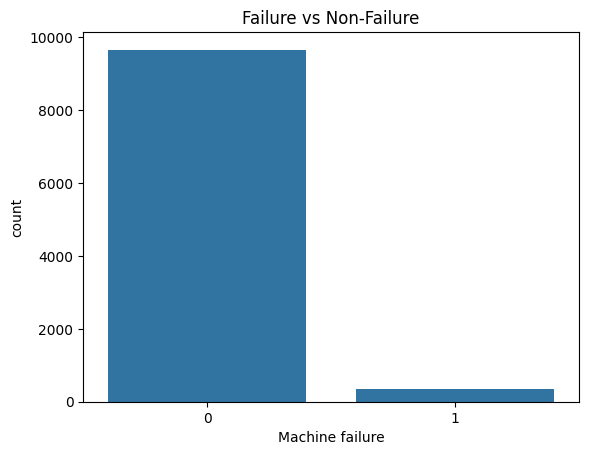

In [17]:
sns.countplot(x='Machine failure', data=df)
plt.title("Failure vs Non-Failure")
plt.show()

The dataset is imbalanced, with significantly fewer failure cases compared to normal cases.
This indicates that accuracy alone is not a reliable evaluation metric.

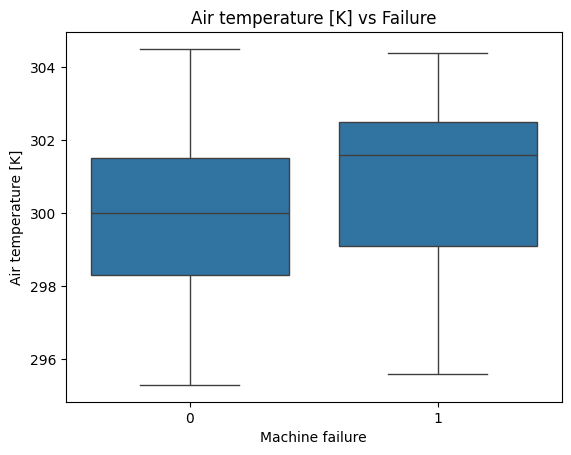

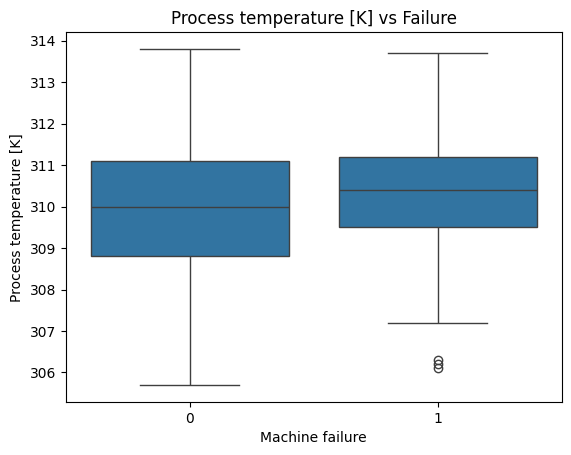

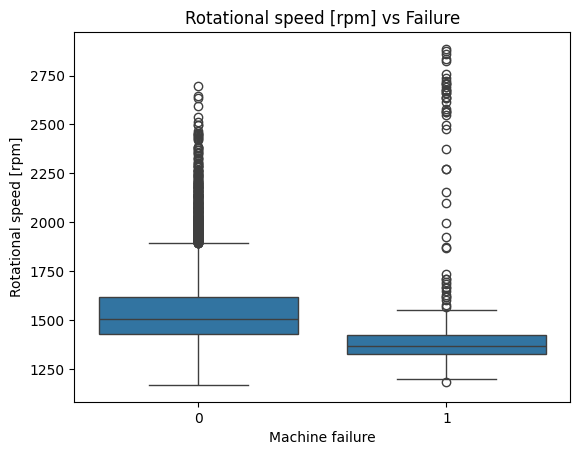

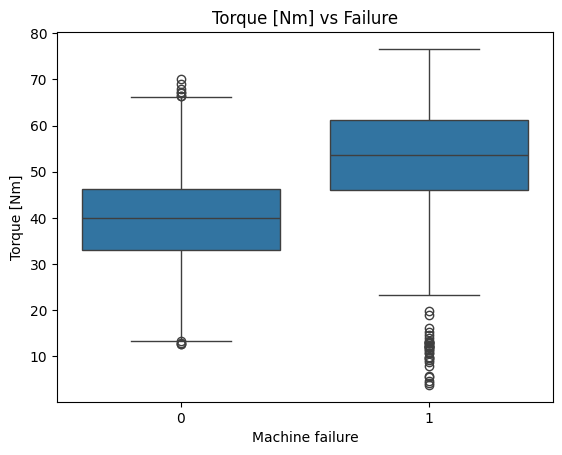

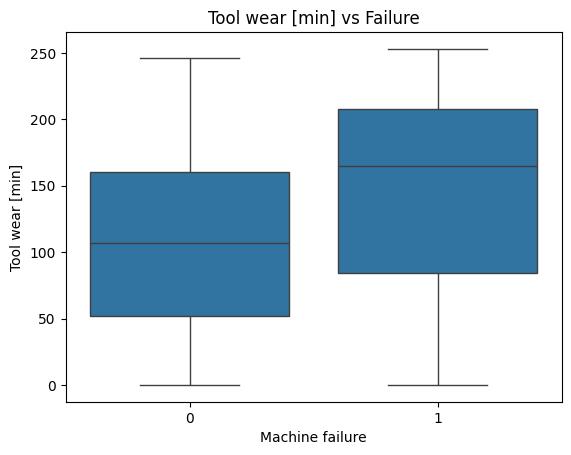

In [18]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for feature in features:
    plt.figure()
    sns.boxplot(x='Machine failure', y=feature, data=df)
    plt.title(f"{feature} vs Failure")
    plt.show()

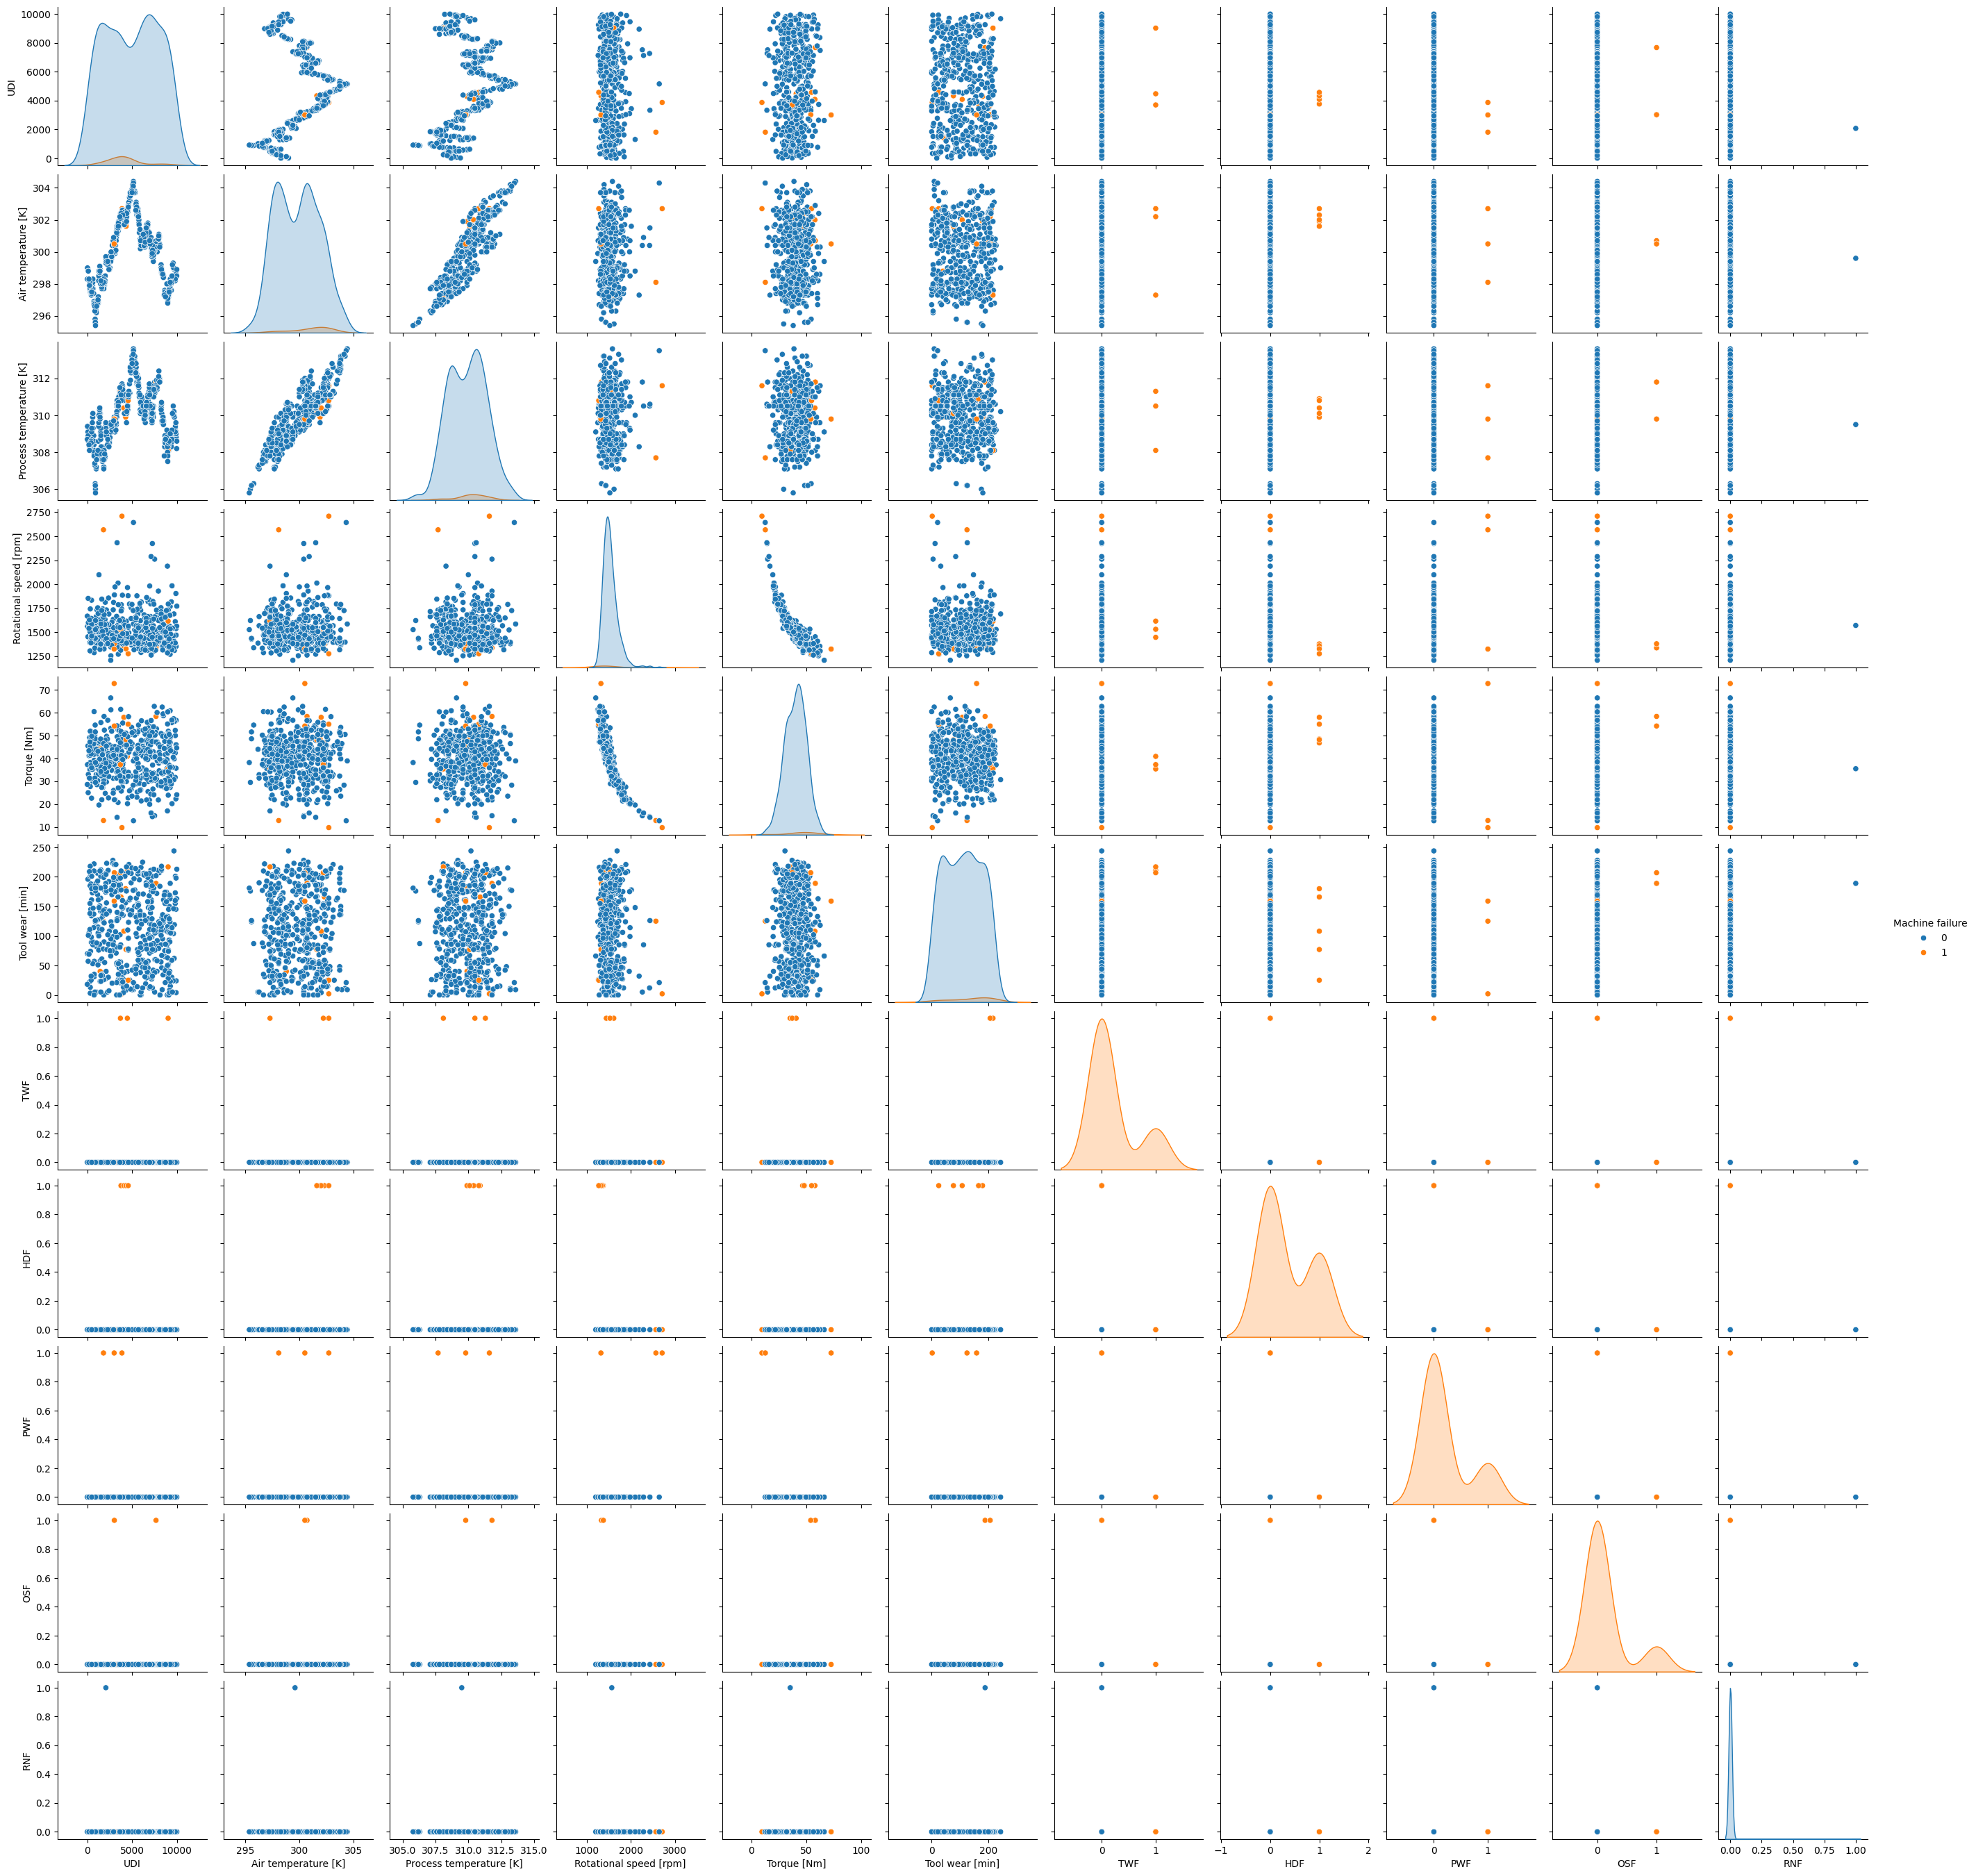

In [19]:
sns.pairplot(df.sample(500), hue='Machine failure')
plt.show()

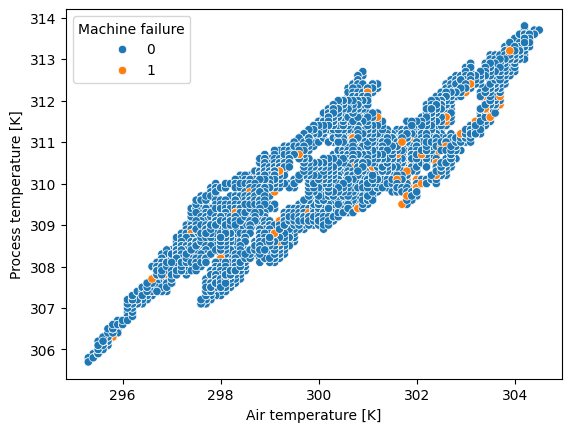

In [20]:
sns.scatterplot(
    x='Air temperature [K]',
    y='Process temperature [K]',
    hue='Machine failure',
    data=df
)
plt.show()

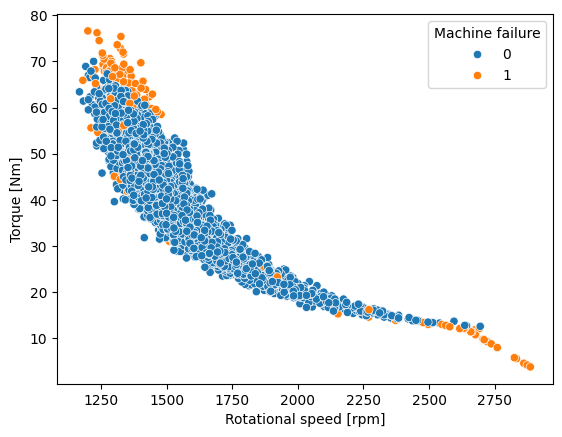

In [21]:
sns.scatterplot(
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    data=df
)
plt.show()

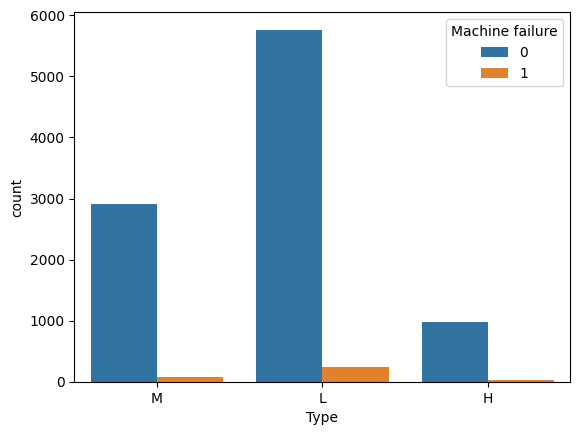

In [22]:
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.show()

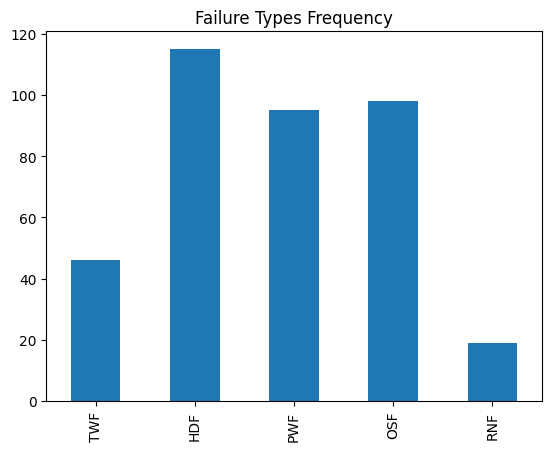

In [23]:
failure_cols = ['TWF','HDF','PWF','OSF','RNF']

df[failure_cols].sum().plot(kind='bar')
plt.title("Failure Types Frequency")
plt.show()

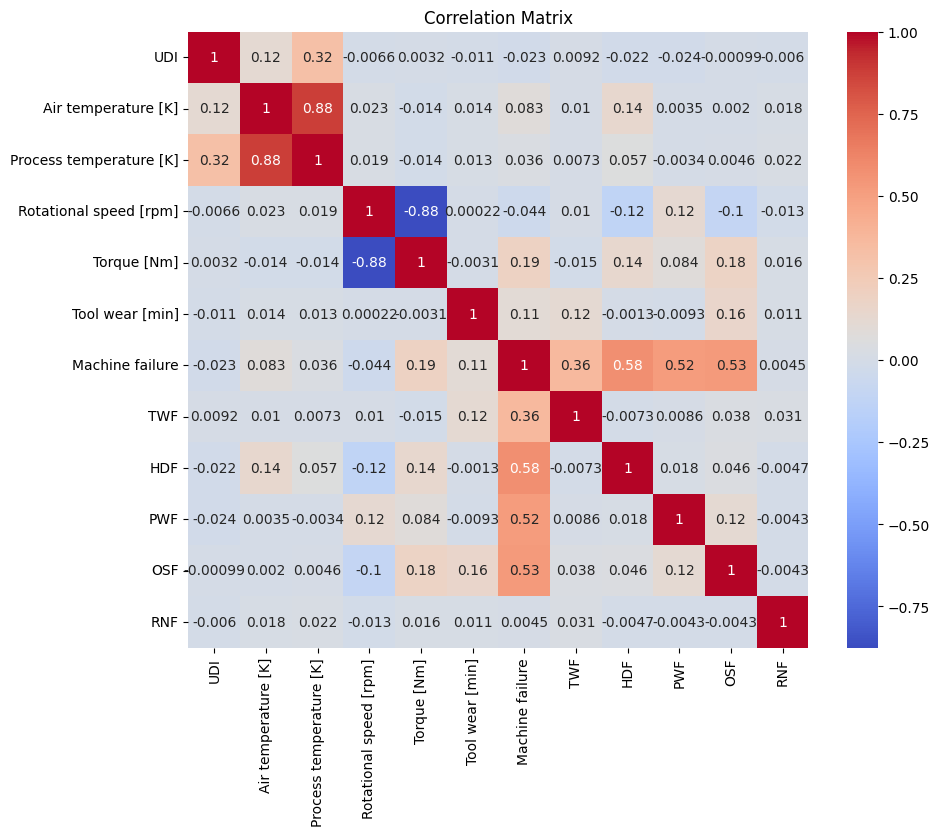

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

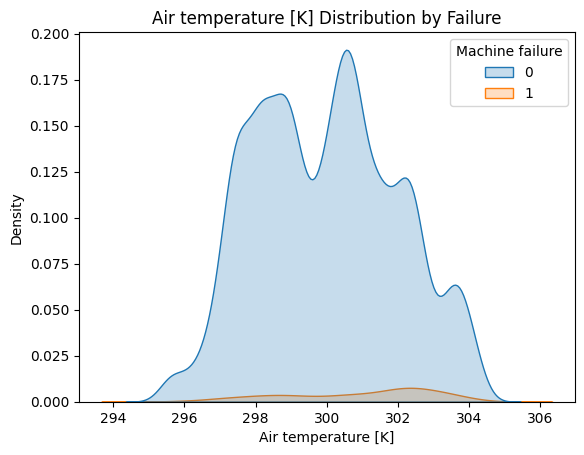

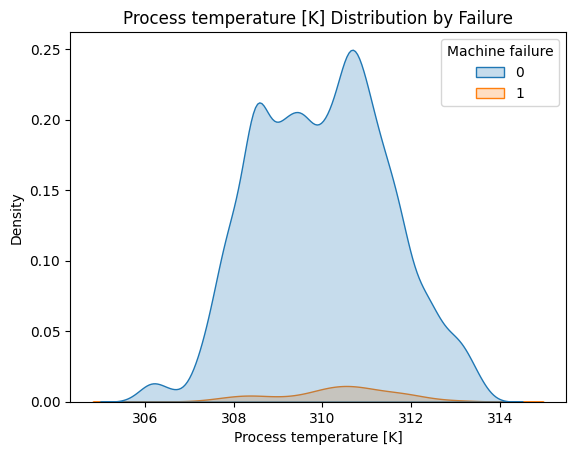

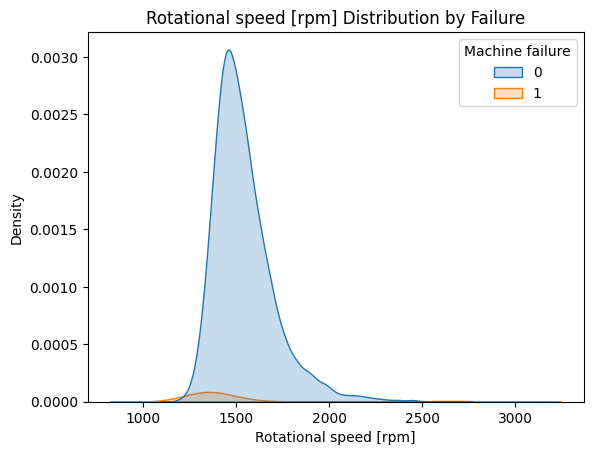

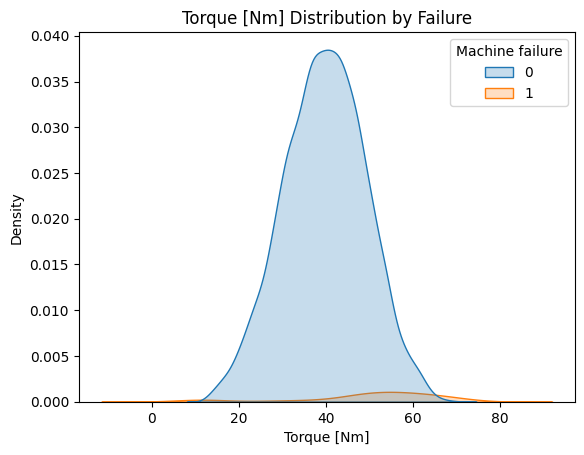

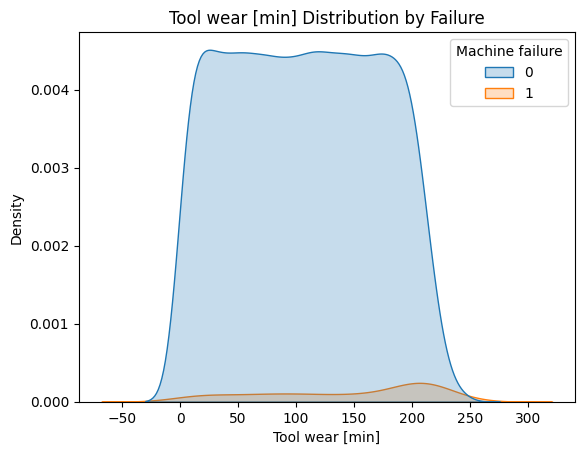

In [25]:
for col in features:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Machine failure', fill=True)
    plt.title(f"{col} Distribution by Failure")
    plt.show()

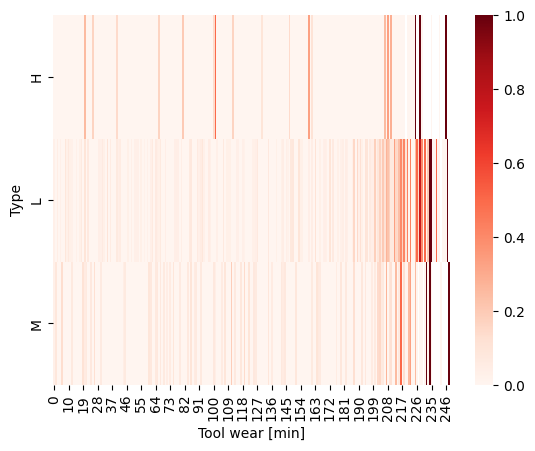

In [26]:
pivot = df.pivot_table(
    values='Machine failure',
    index='Type',
    columns='Tool wear [min]',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='Reds')
plt.show()

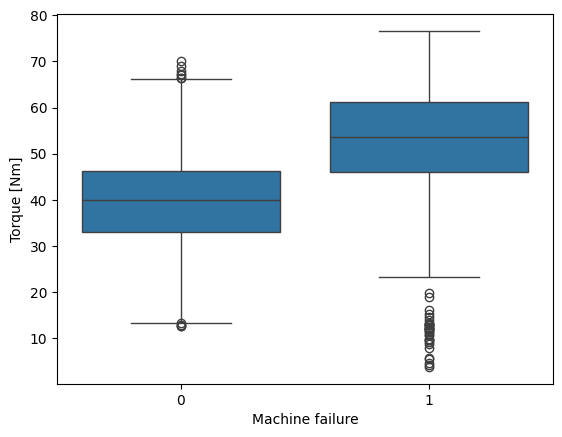

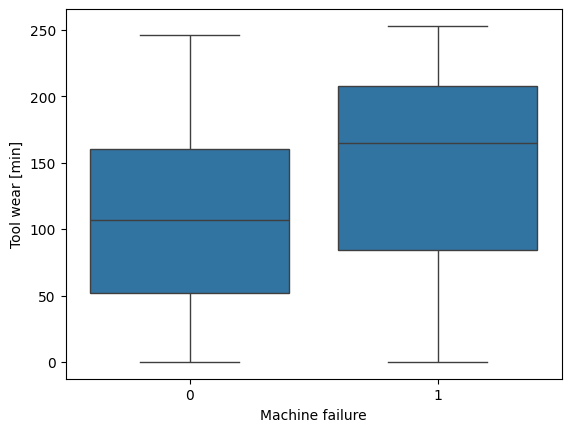

In [27]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()

sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)
plt.show()

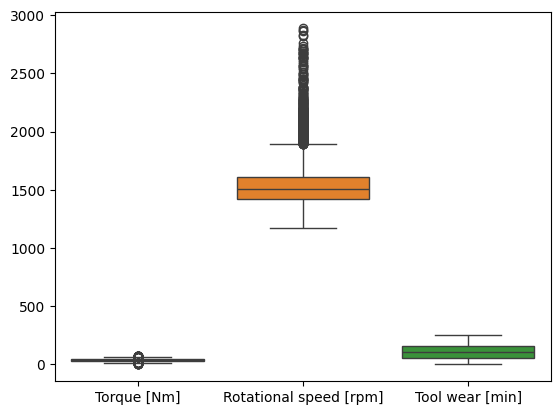

In [28]:
sns.boxplot(data=df[['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]']])
plt.show()

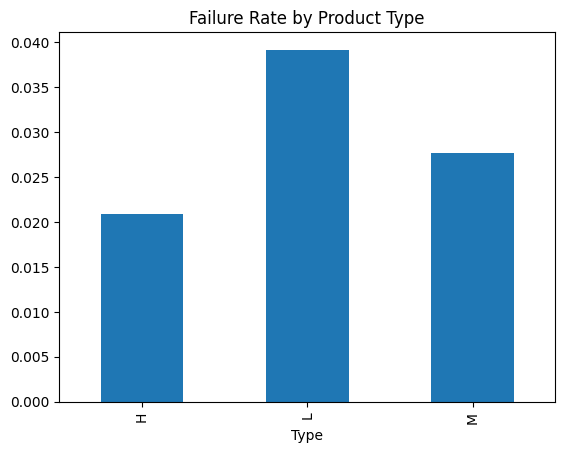

In [29]:
df.groupby('Type')['Machine failure'].mean().plot(kind='bar')
plt.title("Failure Rate by Product Type")
plt.show()

## EDA Interpretation

The exploratory data analysis provided valuable insights into the dataset and the factors influencing machine failure.

The dataset shows a clear class imbalance, where failure cases are significantly fewer than normal operating conditions. This indicates that accuracy alone is not a reliable evaluation metric, and more focus should be given to recall and F1-score when building predictive models.

From the visualizations, tool wear and torque appear to be strong indicators of machine failure. Higher values of tool wear are associated with increased failure probability, which reflects the natural degradation of machine components over time. Similarly, extreme torque values suggest higher mechanical stress, increasing the likelihood of failure.

Temperature-related features, specifically air temperature and process temperature, exhibit a strong correlation with each other. However, their direct relationship with failure is less obvious, suggesting that failure conditions depend on more complex interactions between variables rather than a single factor.

Rotational speed also plays a role in machine performance, with failures tending to occur at extreme speed conditions. Additionally, product type (L, M, H) shows variation in failure rates, indicating that product quality may influence machine reliability.

The analysis of failure modes highlights that different types of failures contribute to the overall machine failure, with some types occurring more frequently than others, while random failures remain rare.

Outliers observed in several features represent extreme but realistic machine operating conditions and should not be removed without careful consideration, as they may contain critical information for predicting failures.

Overall, the EDA demonstrates that machine failure is influenced by multiple interacting factors rather than a single variable, emphasizing the need for robust machine learning models capable of capturing non-linear relationships.

# **Data Handling**

In [6]:
df_clean = df.copy()

In [8]:
df_clean.drop(columns=[
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
], inplace=True)

In [7]:
df_clean = pd.get_dummies(df_clean, columns=["Type"], drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("Machine failure", axis=1)
y = df_clean["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [11]:
print("Before:\n", y_train.value_counts())
print("After:\n", y_train_res.value_counts())

Before:
 Machine failure
0    7729
1     271
Name: count, dtype: int64
After:
 Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=(9661/339)
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred_xgb = xgb_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== XGBoost Evaluation ===")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost Evaluation ===
Accuracy: 0.982

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.79      0.75        68

    accuracy                           0.98      2000
   macro avg       0.85      0.89      0.87      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:

[[1910   22]
 [  14   54]]


XGBoost was selected as the best-performing model because it achieved the highest recall in detecting machine failures, making it more effective for predictive maintenance where identifying failures is more critical than minimizing false alarms.

In [22]:
import joblib
joblib.dump(xgb_model, "model.pkl")

['model.pkl']